In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# BLOCK 1 — Imports + paths + load PWT (Colombia) + basic aggregates
# (Run this first. It only touches pwt110.xlsx.)

import numpy as np
import pandas as pd
from pathlib import Path

BASE_DIR = Path("/Users/carlosrubiano/Documents/DOCS_CARLOS/economía/Linkedin/Growth Accounting/Data/")

pwt_path = BASE_DIR / "pwt110.xlsx"
pwt_raw = pd.read_excel(pwt_path, sheet_name="Data")

# Keep Colombia only
pwt = pwt_raw.loc[pwt_raw["countrycode"] == "COL"].copy()
pwt = pwt.sort_values("year").reset_index(drop=True)

# Keep only key columns (only those that exist)
keep_cols = [c for c in [
    "country", "countrycode", "year",
    "rgdpna", "emp", "avh", "rkna", "hc", "rtfpna"
] if c in pwt.columns]
pwt = pwt[keep_cols].copy()

# Construct hours and productivity
pwt["hours"] = np.where(
    ("emp" in pwt.columns) and ("avh" in pwt.columns),
    pwt["emp"] * pwt["avh"],
    np.nan
)

pwt["y_per_worker"] = pwt["rgdpna"] / pwt["emp"]
pwt["y_per_hour"]   = pwt["rgdpna"] / pwt["hours"]
pwt["k_y"]          = pwt["rkna"] / pwt["rgdpna"]

# Quick sanity checks
print("PWT Colombia shape:", pwt.shape)
print("Years:", int(pwt["year"].min()), "to", int(pwt["year"].max()))
print("Columns:", list(pwt.columns))
pwt.head(10)

PWT Colombia shape: (74, 13)
Years: 1950 to 2023
Columns: ['country', 'countrycode', 'year', 'rgdpna', 'emp', 'avh', 'rkna', 'hc', 'rtfpna', 'hours', 'y_per_worker', 'y_per_hour', 'k_y']


,country,countrycode,year,rgdpna,emp,avh,rkna,hc,rtfpna,hours,y_per_worker,y_per_hour,k_y
0,Colombia,COL,1950,49730.363281,3.428313,2786.89,NaN,1.445645,NaN,9554.331264,14505.782592,5.205007,NaN
1,Colombia,COL,1951,50900.320312,3.497513,2774.03,NaN,1.459104,NaN,9702.206142,14553.289580,5.246263,NaN
2,Colombia,COL,1952,54268.156250,3.567041,2761.23,NaN,1.472689,NaN,9849.421717,15213.772482,5.509781,NaN
3,Colombia,COL,1953,58528.792969,3.631041,2748.49,NaN,1.486401,NaN,9979.880015,16119.011645,5.864679,NaN
4,Colombia,COL,1954,63028.144531,3.695530,2735.81,0.052017,1.500240,0.986785,10110.267759,17055.238516,6.234073,8.253049e-07
5,Colombia,COL,1955,65726.601562,3.770154,2723.18,0.056315,1.514208,0.975388,10266.808617,17433.398587,6.401853,8.568038e-07
6,Colombia,COL,1956,67412.375000,3.849548,2710.61,0.060303,1.527401,0.953640,10434.622933,17511.764342,6.460451,8.945341e-07
7,Colombia,COL,1957,67763.218750,3.928773,2698.11,0.063430,1.540710,0.922653,10600.262164,17247.933619,6.392598,9.360518e-07
8,Colombia,COL,1958,68437.703125,4.009576,2685.65,0.065486,1.554134,0.905778,10768.318646,17068.562275,6.355468,9.568694e-07
9,Colombia,COL,1959,73020.859375,4.087675,2673.26,0.067613,1.567675,0.939849,10927.418323,17863.665209,6.682352,9.259436e-07


In [3]:
# BLOCK 2 — Growth rates + growth accounting decomposition (alpha = 1/3)
# (Runs on the 'pwt' dataframe from Block 1.)

alpha = 1/3

def logdiff(s):
    s = pd.to_numeric(s, errors="coerce")
    return np.log(s).diff()

# Growth rates (log differences)
pwt["g_y_pw"] = logdiff(pwt["y_per_worker"])   # growth of output per worker
pwt["g_y_ph"] = logdiff(pwt["y_per_hour"])     # growth of output per hour
pwt["g_ky"]   = logdiff(pwt["k_y"])            # growth of K/Y
pwt["g_hc"]   = logdiff(pwt["hc"])             # growth of human capital

# Capital deepening term: α/(1−α) * g_{K/Y}
pwt["cap_deepening"] = (alpha/(1-alpha)) * pwt["g_ky"]

# TFP as residual (per worker and per hour versions)
pwt["tfp_resid_pw"] = pwt["g_y_pw"] - pwt["cap_deepening"] - pwt["g_hc"]
pwt["tfp_resid_ph"] = pwt["g_y_ph"] - pwt["cap_deepening"] - pwt["g_hc"]

# Compare with PWT's own TFP growth if available (starts ~1954)
if "rtfpna" in pwt.columns:
    pwt["g_tfp_pwt"] = logdiff(pwt["rtfpna"])

# Keep a clean view from the first year where K/Y exists
pwt_ga = pwt.loc[pwt["k_y"].notna(), [
    "year",
    "g_y_pw", "g_y_ph",
    "g_ky", "g_hc",
    "cap_deepening",
    "tfp_resid_pw", "tfp_resid_ph",
] + (["g_tfp_pwt"] if "g_tfp_pwt" in pwt.columns else [])].copy()

print("Growth accounting sample starts in:", int(pwt_ga["year"].min()))
print("Ends in:", int(pwt_ga["year"].max()))
pwt_ga.head(10)

Growth accounting sample starts in: 1954
Ends in: 2023


,year,g_y_pw,g_y_ph,g_ky,g_hc,cap_deepening,tfp_resid_pw,tfp_resid_ph,g_tfp_pwt
4,1954,0.056458,0.061082,NaN,0.009267,NaN,NaN,NaN,NaN
5,1955,0.021930,0.026558,0.037456,0.009267,0.018728,-0.006065,-0.001438,-0.011617
6,1956,0.004485,0.009112,0.043094,0.008675,0.021547,-0.025737,-0.021111,-0.022549
7,1957,-0.015181,-0.010558,0.045368,0.008675,0.022684,-0.046540,-0.041918,-0.033033
8,1958,-0.010454,-0.005825,0.021996,0.008675,0.010998,-0.030127,-0.025499,-0.018458
9,1959,0.045530,0.050155,-0.032854,0.008675,-0.016427,0.053282,0.057906,0.036925
10,1960,0.032652,0.037279,-0.008229,0.008675,-0.004114,0.028091,0.032718,0.017845
11,1961,0.030682,0.032868,-0.004165,0.006311,-0.002082,0.026454,0.028639,0.014733
12,1962,0.021467,0.023654,-0.009109,0.006311,-0.004554,0.019711,0.021898,0.012995
13,1963,0.004002,0.006190,0.002841,0.006311,0.001420,-0.003730,-0.001542,-0.001557


In [4]:
# BLOCK 3 — Average growth decomposition by subperiods

# Define periods (you can adjust if needed)
periods = [
    (1954, 1980),
    (1981, 2000),
    (2001, 2023)
]

results = []

for start, end in periods:
    
    temp = pwt_ga[(pwt_ga["year"] >= start) & (pwt_ga["year"] <= end)]
    
    avg = {
        "period": f"{start}-{end}",
        "g_y": temp["g_y_pw"].mean(),
        "capital_deepening": temp["cap_deepening"].mean(),
        "human_capital": temp["g_hc"].mean(),
        "tfp_residual": temp["tfp_resid_pw"].mean()
    }
    
    results.append(avg)

ga_table = pd.DataFrame(results)

# Convert to percentage terms (more readable)
ga_table_pct = ga_table.copy()

for c in ga_table_pct.columns[1:]:
    ga_table_pct[c] = ga_table_pct[c] * 100

print("Growth Accounting Table (% per year)")
display(ga_table_pct.round(2))

Growth Accounting Table (% per year)


,period,g_y,capital_deepening,human_capital,tfp_residual
0,1954-1980,2.02,0.14,0.69,1.07
1,1981-2000,0.03,0.53,0.95,-1.44
2,2001-2023,1.50,0.14,0.94,0.42


In [5]:
# BLOCK 4 — Load GGDC 10-sector dataset and inspect structure

ggdc_path = BASE_DIR / "10sd_jan15_2014 (1).xlsx"

ggdc_raw = pd.read_excel(ggdc_path, sheet_name="dataset")

print("Shape:", ggdc_raw.shape)
print()

print("Columns:")
print(ggdc_raw.columns)
print()

print("Variables available:")
print(ggdc_raw["Variable"].unique())
print()

print("Countries sample:")
print(ggdc_raw["Country"].unique()[:10])
print()

# Check Colombia rows
ggdc_col = ggdc_raw[ggdc_raw["Country"] == "COL"]

print("Colombia rows:", ggdc_col.shape)
print()

print("Variables for Colombia:")
print(ggdc_col["Variable"].unique())

ggdc_col.head()

Shape: (7556, 16)

Columns:
Index(['Country', 'Region code', 'Region', 'Variable', 'Year', 'Agriculture ',
       'Mining', 'Manufacturing', 'Utilities', 'Construction',
       'Trade, restaurants and hotels', 'Transport, storage and communication',
       'Finance, insurance, real estate and business services',
       'Government services', 'Community, social and personal services',
       'Summation of sector GDP'],
      dtype='object')

Variables available:
['VA' 'VA_Q05' 'EMP' 'VA_Q10' 'VA_Q91']

Countries sample:
['BWA' 'ETH' 'GHA' 'KEN' 'MWI' 'MUS' 'NGA' 'NGA(alt)' 'SEN' 'ZAF']

Colombia rows: (185, 16)

Variables for Colombia:
['VA' 'VA_Q05' 'EMP']


,Country,Region code,Region,Variable,Year,Agriculture,Mining,Manufacturing,Utilities,Construction,"Trade, restaurants and hotels","Transport, storage and communication","Finance, insurance, real estate and business services",Government services,"Community, social and personal services",Summation of sector GDP
4529,COL,LAM,Latin America,VA,1950,3305.058761,222.823828,1818.056806,50.346112,355.462761,1600.403907,589.199315,753.531826,NaN,1364.569874,10059.45319
4530,COL,LAM,Latin America,VA,1951,3632.473171,286.487779,1995.259811,56.339697,379.698859,1584.744378,714.232890,868.767279,NaN,1538.575428,11056.57929
4531,COL,LAM,Latin America,VA,1952,3858.712312,350.151730,2209.284220,62.333281,412.013655,1819.637319,782.744438,922.783897,NaN,1749.213731,12166.874583
4532,COL,LAM,Latin America,VA,1953,4290.112414,369.604603,2819.138718,82.711469,488.761297,2110.904566,856.394353,959.695253,NaN,1895.744724,13873.067398
4533,COL,LAM,Latin America,VA,1954,5002.554928,394.362807,3205.763456,83.910186,618.020483,2489.865179,988.279083,1027.216026,NaN,2157.668874,15967.641021


In [7]:
# BLOCK 5 (fixed) — Clean GGDC sector dataset and compute sector productivity

ggdc = ggdc_raw[
    (ggdc_raw["Country"] == "COL") &
    (ggdc_raw["Variable"].isin(["VA_Q05", "EMP"]))
].copy()

sector_cols = [
    'Agriculture ',
    'Mining',
    'Manufacturing',
    'Utilities',
    'Construction',
    'Trade, restaurants and hotels',
    'Transport, storage and communication',
    'Finance, insurance, real estate and business services',
    'Government services',
    'Community, social and personal services'
]

ggdc_long = ggdc.melt(
    id_vars=["Country", "Variable", "Year"],
    value_vars=sector_cols,
    var_name="sector",
    value_name="value"
)

ggdc_panel = ggdc_long.pivot_table(
    index=["Year", "sector"],
    columns="Variable",
    values="value",
    aggfunc="first"
).reset_index()

# Force numeric
ggdc_panel["VA_Q05"] = pd.to_numeric(ggdc_panel["VA_Q05"], errors="coerce")
ggdc_panel["EMP"]    = pd.to_numeric(ggdc_panel["EMP"], errors="coerce")

# Productivity
ggdc_panel["y_per_worker"] = ggdc_panel["VA_Q05"] / ggdc_panel["EMP"]

# Sort properly
ggdc_panel = ggdc_panel.sort_values(["sector", "Year"]).reset_index(drop=True)

# Sector-specific log growth
ggdc_panel["g_y_sector"] = ggdc_panel.groupby("sector")["y_per_worker"].transform(
    lambda s: np.log(s).diff()
)

# Quick checks
print("Panel shape:", ggdc_panel.shape)
print("Dtypes:\n", ggdc_panel.dtypes)
ggdc_panel.head(12)

Panel shape: (558, 6)
Dtypes:
 Variable
Year              int64
sector           object
EMP             float64
VA_Q05          float64
y_per_worker    float64
g_y_sector      float64
dtype: object


Variable,Year,sector,EMP,VA_Q05,y_per_worker,g_y_sector
0,1950,Agriculture,2093.994796,4.957536e+06,2367.501530,NaN
1,1951,Agriculture,2097.077237,5.019056e+06,2393.357889,0.010862
2,1952,Agriculture,2145.389022,5.360906e+06,2498.803824,0.043115
3,1953,Agriculture,2094.797233,5.379240e+06,2567.904869,0.027278
4,1954,Agriculture,2073.760667,5.522123e+06,2662.854777,0.036308
5,1955,Agriculture,2092.397814,5.661847e+06,2705.913253,0.016041
6,1956,Agriculture,2119.546432,5.848854e+06,2759.483573,0.019604
7,1957,Agriculture,2174.104279,6.213071e+06,2857.761335,0.034995
8,1958,Agriculture,2278.454285,6.408983e+06,2812.864339,-0.015835
9,1959,Agriculture,2302.908380,6.708193e+06,2912.922373,0.034954


In [8]:
# BLOCK 6 — Average productivity growth by sector

sector_growth = (
    ggdc_panel
    .dropna(subset=["g_y_sector"])
    .groupby("sector")
    .agg(
        avg_growth=("g_y_sector", "mean"),
        start_year=("Year", "min"),
        end_year=("Year", "max")
    )
    .reset_index()
)

# Convert to percent
sector_growth["avg_growth_pct"] = sector_growth["avg_growth"] * 100

# Sort
sector_growth = sector_growth.sort_values("avg_growth_pct", ascending=False)

print("Sector productivity growth (% per year)")
display(sector_growth.round(2))

print("\nFastest productivity growth sector:")
display(sector_growth.head(1))

print("\nSlowest productivity growth sector:")
display(sector_growth.tail(1))

Sector productivity growth (% per year)


,sector,avg_growth,start_year,end_year,avg_growth_pct
8,Utilities,0.03,1951,2010,3.11
3,"Finance, insurance, real estate and business s...",0.02,1951,2010,1.98
0,Agriculture,0.02,1951,2010,1.83
4,Manufacturing,0.01,1951,2010,1.38
1,"Community, social and personal services",0.01,1951,2010,1.35
7,"Transport, storage and communication",0.01,1951,2010,1.17
5,Mining,0.01,1951,2010,0.94
2,Construction,0.00,1951,2010,0.24
6,"Trade, restaurants and hotels",-0.02,1951,2010,-1.99



Fastest productivity growth sector:


,sector,avg_growth,start_year,end_year,avg_growth_pct
8,Utilities,0.031112,1951,2010,3.11115



Slowest productivity growth sector:


,sector,avg_growth,start_year,end_year,avg_growth_pct
6,"Trade, restaurants and hotels",-0.019944,1951,2010,-1.99444


In [9]:
# BLOCK 7 — Aggregate productivity reconstructed from sectors

agg_sector = (
    ggdc_panel
    .groupby("Year")
    .agg(
        VA_total=("VA_Q05", "sum"),
        EMP_total=("EMP", "sum")
    )
    .reset_index()
)

agg_sector["y_sector_agg"] = agg_sector["VA_total"] / agg_sector["EMP_total"]

# growth
agg_sector["g_y_sector_agg"] = np.log(agg_sector["y_sector_agg"]).diff()

print("Aggregate productivity reconstructed from sectors")
agg_sector.head()

Aggregate productivity reconstructed from sectors


,Year,VA_total,EMP_total,y_sector_agg,g_y_sector_agg
0,1950,2.537430e+07,3710.199058,6839.066201,NaN
1,1951,2.663263e+07,3780.523943,7044.692654,0.029623
2,1952,2.831972e+07,3852.181800,7351.605124,0.042644
3,1953,3.102145e+07,3925.197894,7903.156268,0.072344
4,1954,3.406401e+07,3999.597969,8516.858106,0.074785


In [10]:
# BLOCK 8 — Compare sector aggregation with PWT aggregate

comparison = pwt.merge(
    agg_sector,
    left_on="year",
    right_on="Year",
    how="inner"
)

comparison = comparison[[
    "year",
    "y_per_worker",
    "y_sector_agg"
]]

comparison.head()

,year,y_per_worker,y_sector_agg
0,1950,14505.782592,6839.066201
1,1951,14553.289580,7044.692654
2,1952,15213.772482,7351.605124
3,1953,16119.011645,7903.156268
4,1954,17055.238516,8516.858106


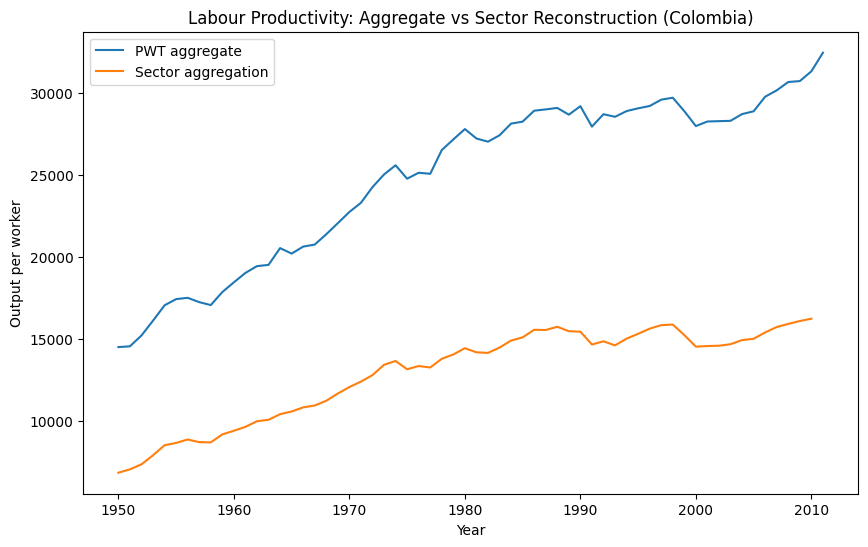

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(comparison["year"], comparison["y_per_worker"], label="PWT aggregate")
plt.plot(comparison["year"], comparison["y_sector_agg"], label="Sector aggregation")

plt.legend()
plt.title("Labour Productivity: Aggregate vs Sector Reconstruction (Colombia)")
plt.xlabel("Year")
plt.ylabel("Output per worker")

plt.show()

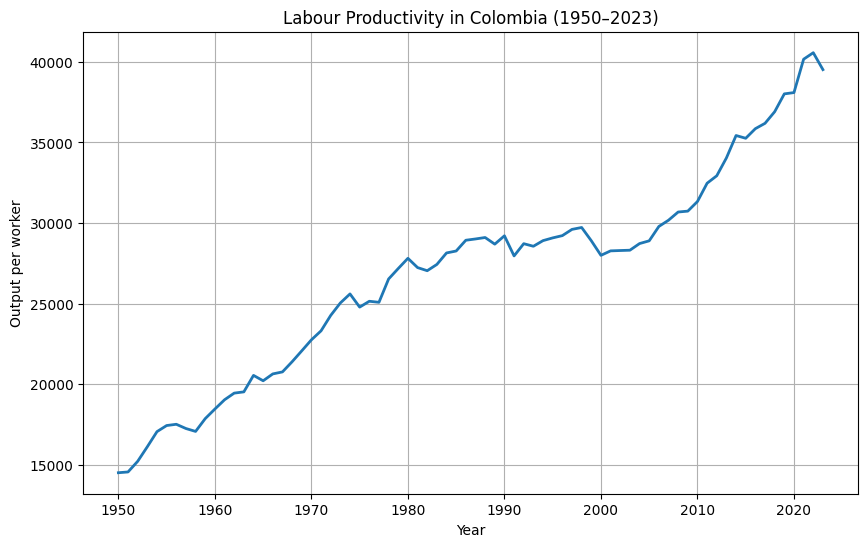

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(pwt["year"], pwt["y_per_worker"], linewidth=2)

plt.title("Labour Productivity in Colombia (1950–2023)")
plt.xlabel("Year")
plt.ylabel("Output per worker")

plt.grid(True)

plt.show()

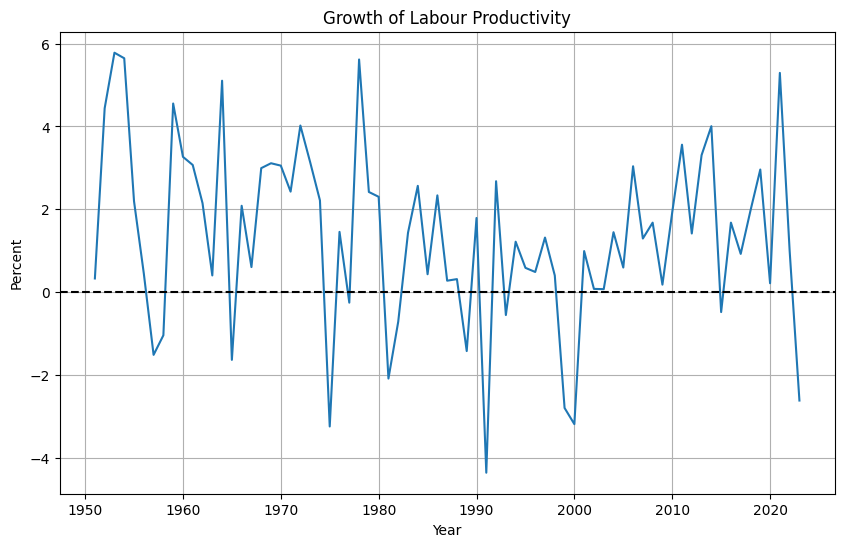

In [13]:
plt.figure(figsize=(10,6))

plt.plot(pwt["year"], pwt["g_y_pw"]*100, linewidth=1.5)

plt.axhline(0, color="black", linestyle="--")

plt.title("Growth of Labour Productivity")
plt.xlabel("Year")
plt.ylabel("Percent")

plt.grid(True)

plt.show()

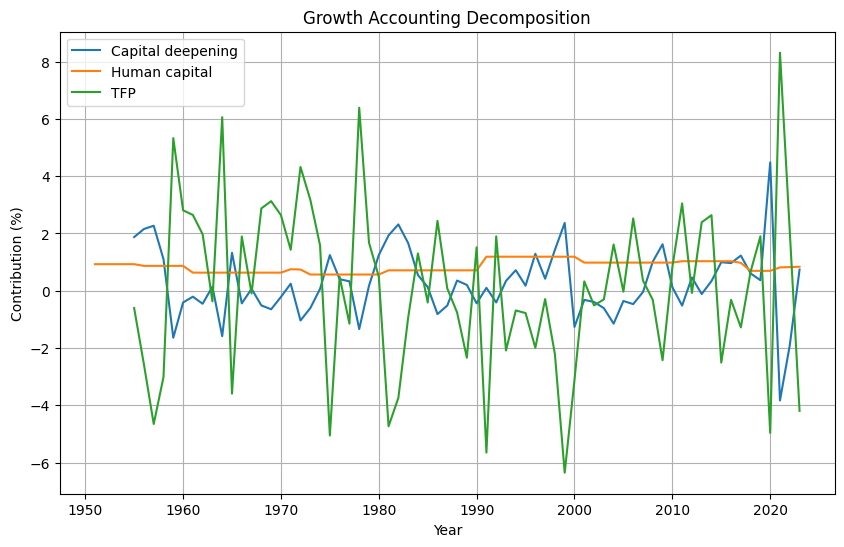

In [14]:
plt.figure(figsize=(10,6))

plt.plot(pwt["year"], pwt["cap_deepening"]*100, label="Capital deepening")
plt.plot(pwt["year"], pwt["g_hc"]*100, label="Human capital")
plt.plot(pwt["year"], pwt["tfp_resid_pw"]*100, label="TFP")

plt.legend()

plt.title("Growth Accounting Decomposition")
plt.xlabel("Year")
plt.ylabel("Contribution (%)")

plt.grid(True)

plt.show()

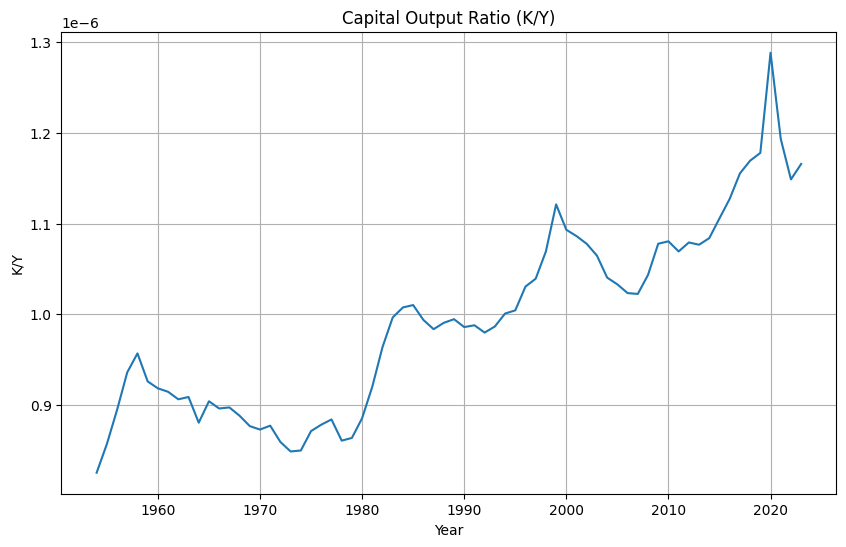

In [15]:
plt.figure(figsize=(10,6))

plt.plot(pwt["year"], pwt["k_y"])

plt.title("Capital Output Ratio (K/Y)")
plt.xlabel("Year")
plt.ylabel("K/Y")

plt.grid(True)

plt.show()

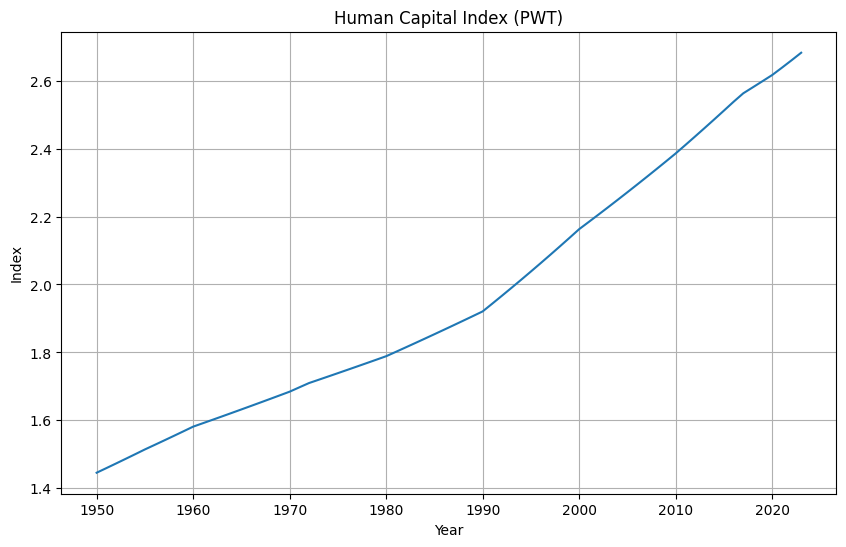

In [16]:
plt.figure(figsize=(10,6))

plt.plot(pwt["year"], pwt["hc"])

plt.title("Human Capital Index (PWT)")
plt.xlabel("Year")
plt.ylabel("Index")

plt.grid(True)

plt.show()

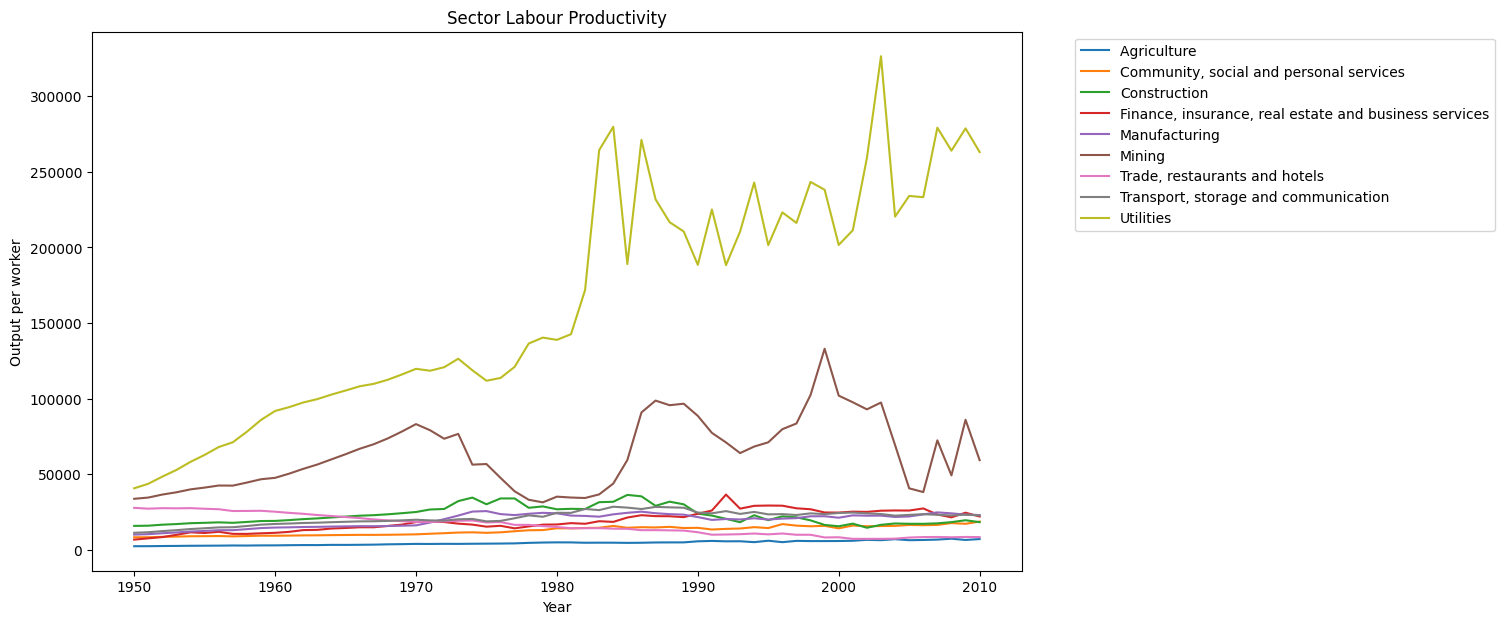

In [18]:
plt.figure(figsize=(12,7))

for s in ggdc_panel["sector"].unique():
    
    data = ggdc_panel[ggdc_panel["sector"]==s]
    
    plt.plot(data["Year"], data["y_per_worker"], label=s)

plt.legend(bbox_to_anchor=(1.05,1))

plt.title("Sector Labour Productivity")
plt.xlabel("Year")
plt.ylabel("Output per worker")

plt.show()

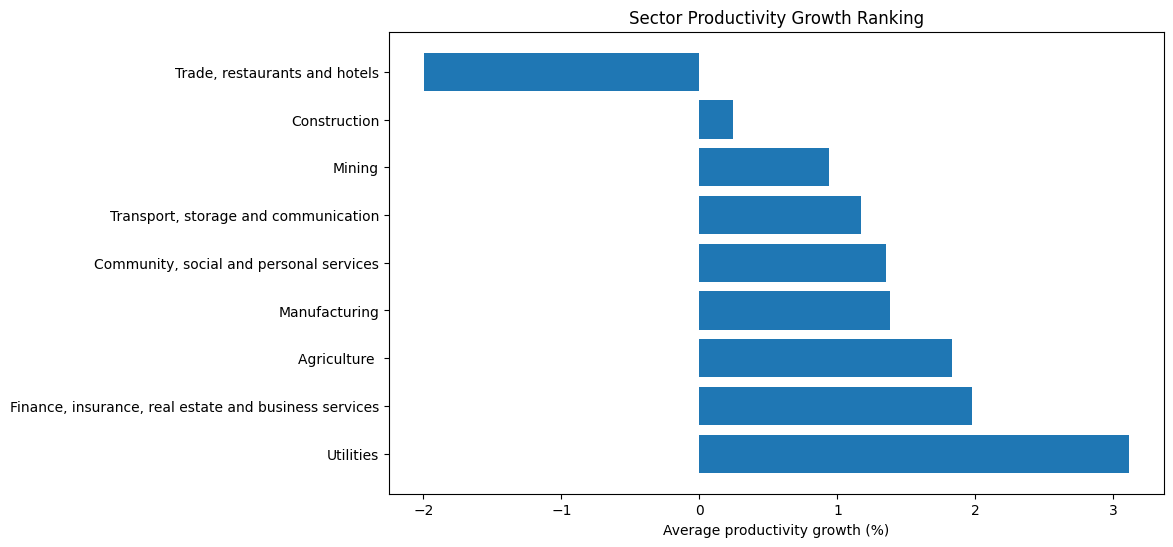

In [19]:
plt.figure(figsize=(10,6))

plt.barh(sector_growth["sector"], sector_growth["avg_growth_pct"])

plt.xlabel("Average productivity growth (%)")
plt.title("Sector Productivity Growth Ranking")

plt.show()

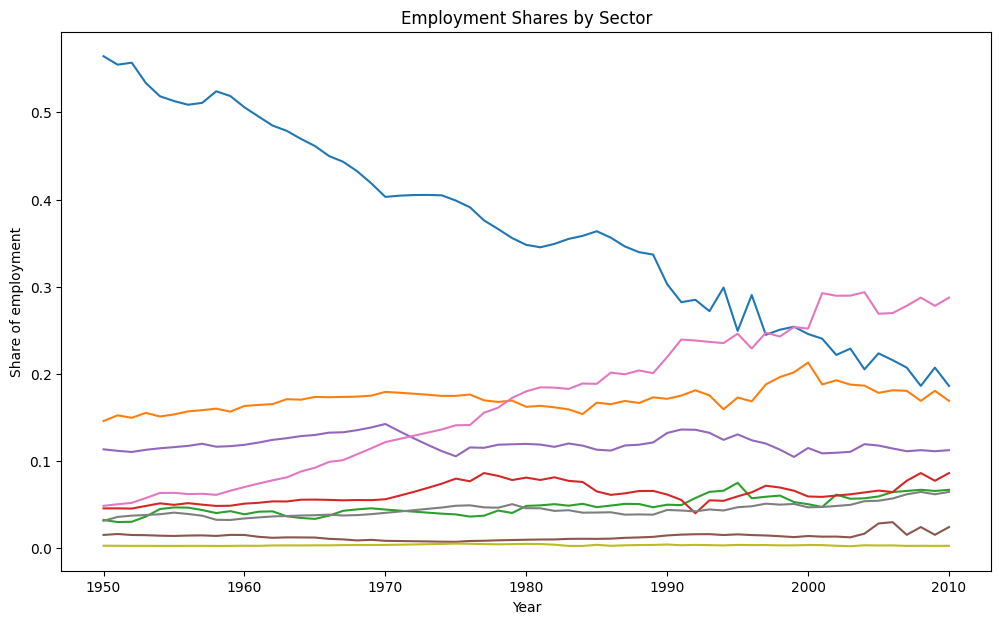

In [20]:
emp = ggdc_panel.pivot(index="Year", columns="sector", values="EMP")

emp_share = emp.div(emp.sum(axis=1), axis=0)

plt.figure(figsize=(12,7))

for c in emp_share.columns:
    
    plt.plot(emp_share.index, emp_share[c])

plt.title("Employment Shares by Sector")
plt.xlabel("Year")
plt.ylabel("Share of employment")

plt.show()

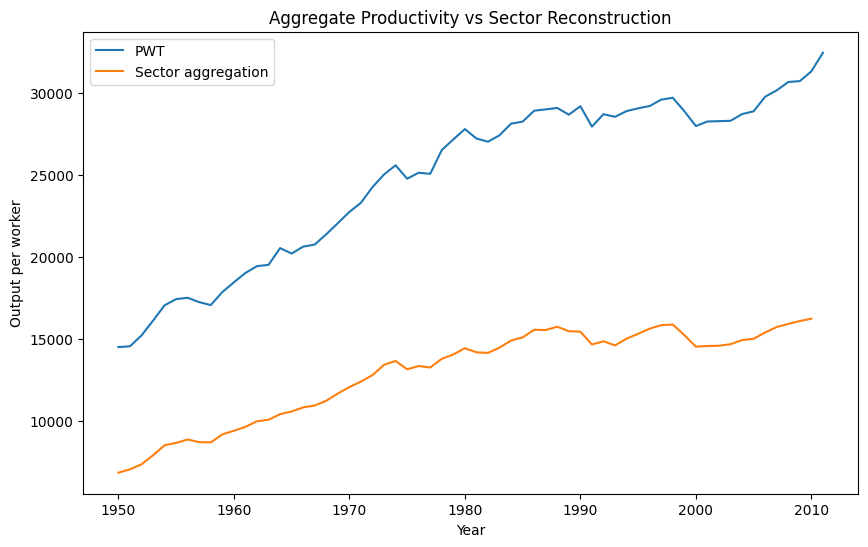

In [21]:
plt.figure(figsize=(10,6))

plt.plot(comparison["year"], comparison["y_per_worker"], label="PWT")
plt.plot(comparison["year"], comparison["y_sector_agg"], label="Sector aggregation")

plt.legend()

plt.title("Aggregate Productivity vs Sector Reconstruction")
plt.xlabel("Year")
plt.ylabel("Output per worker")

plt.show()

/var/folders/hr/z0hgfhdn3tbc9dtd9gq9gs140000gn/T/ipykernel_71618/3539803424.py:34: RuntimeWarning: divide by zero encountered in log
  dlnP = np.log(P1) - np.log(P0)


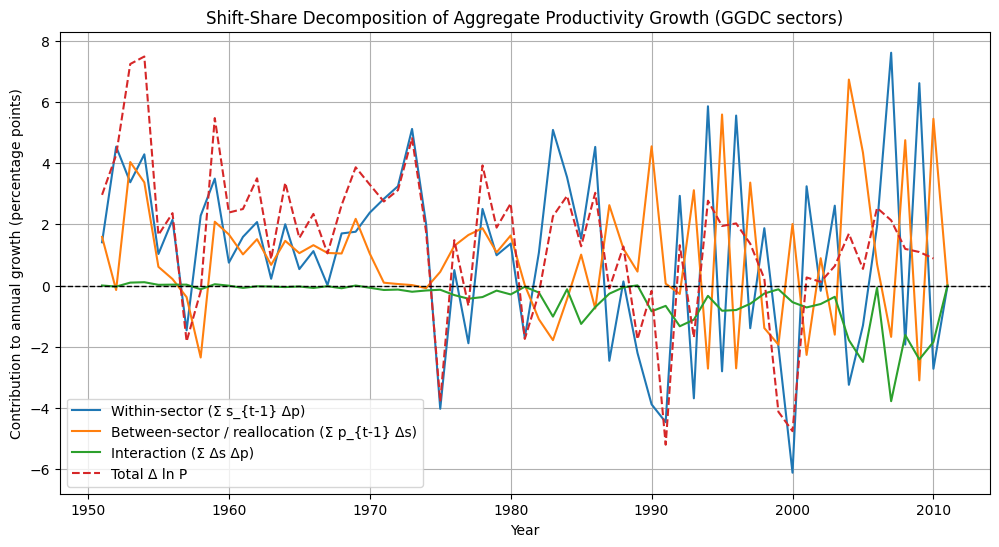

Mean absolute gap |total - sum(components)|: inf


In [22]:
# BLOCK A — Shift-share decomposition of aggregate labour productivity growth
# Decompose Δ ln P_t into: within-sector + between-sector (reallocation) + interaction
# using ggdc_panel (Year, sector, VA_Q05, EMP, y_per_worker).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build shares and levels
va_wide  = ggdc_panel.pivot(index="Year", columns="sector", values="VA_Q05").sort_index()
emp_wide = ggdc_panel.pivot(index="Year", columns="sector", values="EMP").sort_index()

p = va_wide / emp_wide                         # sector productivity
s = emp_wide.div(emp_wide.sum(axis=1), axis=0) # employment shares

years = p.index

# Components per year t (from t-1 to t)
within = []
between = []
interaction = []
dy = []

for t in range(1, len(years)):
    y0, y1 = years[t-1], years[t]
    p0, p1 = p.loc[y0], p.loc[y1]
    s0, s1 = s.loc[y0], s.loc[y1]
    
    # aggregate productivity levels
    P0 = (s0 * p0).sum()
    P1 = (s1 * p1).sum()
    
    # total log change
    dlnP = np.log(P1) - np.log(P0)
    dy.append(dlnP)
    
    # shift-share in log terms (approx): divide level contributions by P0
    dp = (p1 - p0)
    ds = (s1 - s0)
    
    within_t = (s0 * dp).sum() / P0
    between_t = (p0 * ds).sum() / P0
    interaction_t = (ds * dp).sum() / P0
    
    within.append(within_t)
    between.append(between_t)
    interaction.append(interaction_t)

shift_df = pd.DataFrame({
    "Year": years[1:],
    "dlnP": dy,
    "within": within,
    "between": between,
    "interaction": interaction
})

# Plot: contributions in % points to annual log growth
plt.figure(figsize=(12,6))
plt.plot(shift_df["Year"], shift_df["within"]*100, label="Within-sector (Σ s_{t-1} Δp)")
plt.plot(shift_df["Year"], shift_df["between"]*100, label="Between-sector / reallocation (Σ p_{t-1} Δs)")
plt.plot(shift_df["Year"], shift_df["interaction"]*100, label="Interaction (Σ Δs Δp)")
plt.plot(shift_df["Year"], shift_df["dlnP"]*100, linestyle="--", label="Total Δ ln P")

plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.title("Shift-Share Decomposition of Aggregate Productivity Growth (GGDC sectors)")
plt.xlabel("Year")
plt.ylabel("Contribution to annual growth (percentage points)")
plt.legend()
plt.grid(True)
plt.show()

# Optional quick check: total approx equals sum of components
print("Mean absolute gap |total - sum(components)|:",
      float(np.mean(np.abs(shift_df["dlnP"] - (shift_df["within"]+shift_df["between"]+shift_df["interaction"])))))

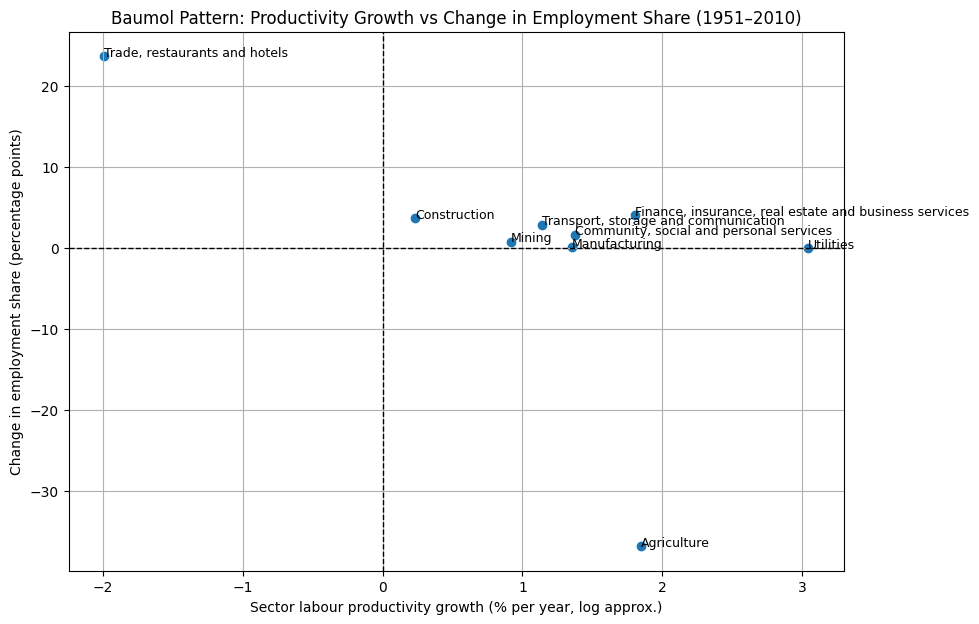

In [23]:
# BLOCK B — Baumol-style plot: Productivity growth vs Employment share change (1951–2010)
# Shows whether sectors with low productivity growth gained employment share.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

va_wide  = ggdc_panel.pivot(index="Year", columns="sector", values="VA_Q05").sort_index()
emp_wide = ggdc_panel.pivot(index="Year", columns="sector", values="EMP").sort_index()
p = va_wide / emp_wide
s = emp_wide.div(emp_wide.sum(axis=1), axis=0)

start_year, end_year = 1951, 2010
p_start, p_end = p.loc[start_year], p.loc[end_year]
s_start, s_end = s.loc[start_year], s.loc[end_year]

# Avg annual productivity growth (log) over the period
g_p = (np.log(p_end) - np.log(p_start)) / (end_year - start_year) * 100  # % per year (approx)
# Change in employment share in percentage points
ds_pp = (s_end - s_start) * 100

baumol_df = pd.DataFrame({
    "sector": p.columns,
    "prod_growth_pct_per_year": g_p.values,
    "emp_share_change_pp": ds_pp.values,
    "emp_share_start": (s_start*100).values,
    "emp_share_end": (s_end*100).values
}).dropna()

plt.figure(figsize=(10,7))
plt.scatter(baumol_df["prod_growth_pct_per_year"], baumol_df["emp_share_change_pp"])

# Label points
for _, r in baumol_df.iterrows():
    plt.text(r["prod_growth_pct_per_year"], r["emp_share_change_pp"], str(r["sector"]).strip(), fontsize=9)

plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.axvline(0, linestyle="--", color="black", linewidth=1)

plt.title("Baumol Pattern: Productivity Growth vs Change in Employment Share (1951–2010)")
plt.xlabel("Sector labour productivity growth (% per year, log approx.)")
plt.ylabel("Change in employment share (percentage points)")
plt.grid(True)
plt.show()

Available years range: 1950 to 2011
Years requested: [1951, 1980, 2010]
Missing years: []

Top 3 productivity sectors in 1951:
                       sector         prod
                    Utilities 43668.060048
                       Mining 34547.509094
Trade, restaurants and hotels 27201.083400


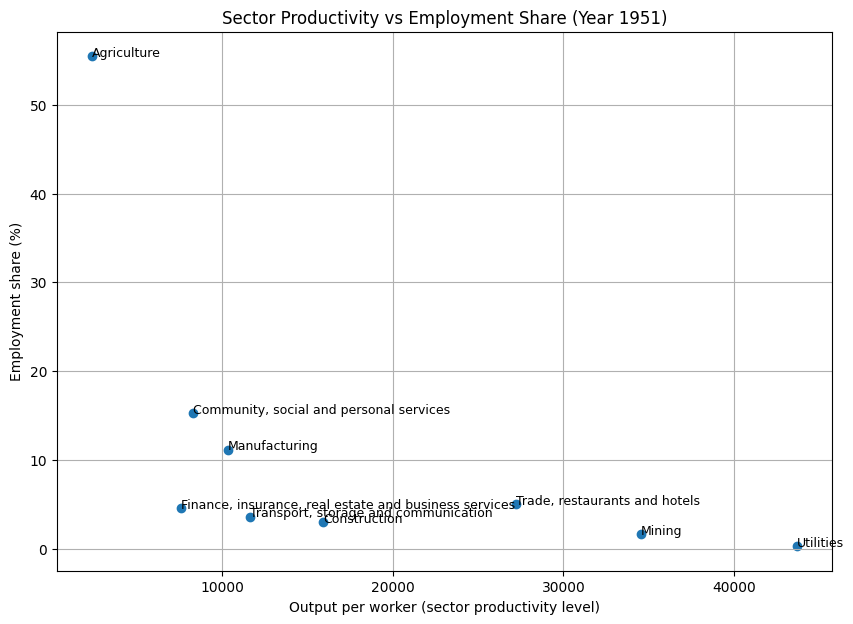


Top 3 productivity sectors in 1980:
      sector          prod
   Utilities 138848.352227
      Mining  35153.923361
Construction  26799.428521


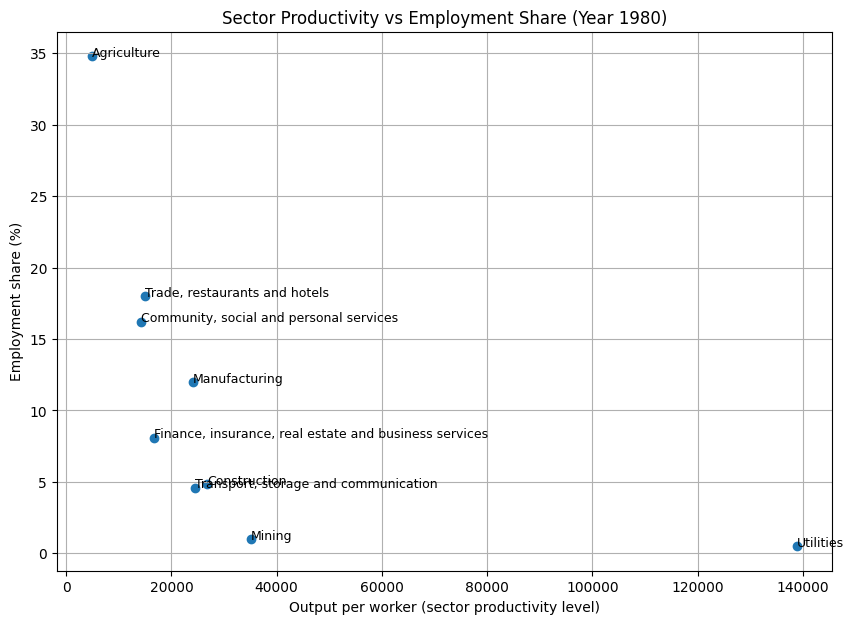


Top 3 productivity sectors in 2010:
       sector          prod
    Utilities 263077.823118
       Mining  59279.961255
Manufacturing  22982.049574


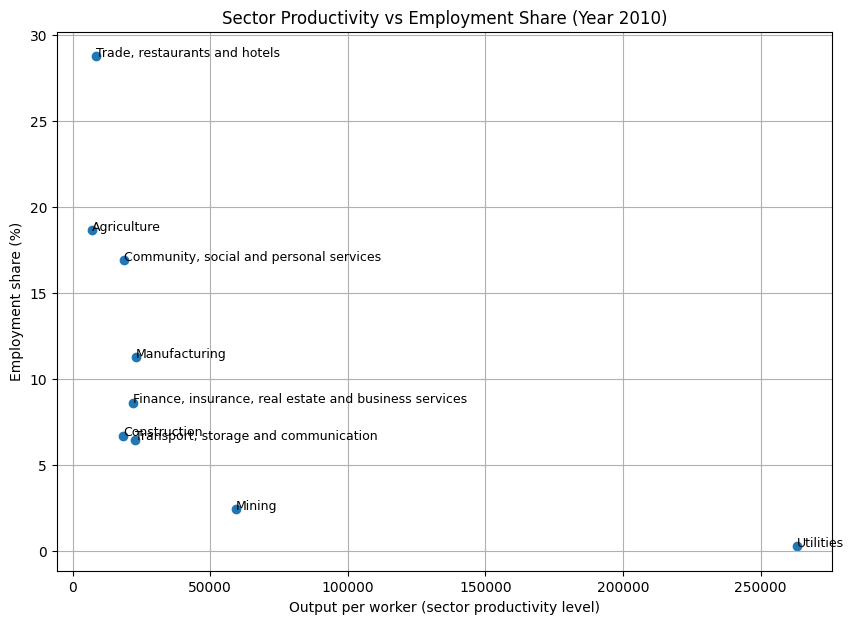

In [25]:
# BLOCK C (fixed) — Sector productivity vs employment share (scatter) for multiple years

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Force Year to int in ggdc_panel (safe even if already int)
ggdc_panel["Year"] = ggdc_panel["Year"].astype(int)

va_wide  = ggdc_panel.pivot(index="Year", columns="sector", values="VA_Q05").sort_index()
emp_wide = ggdc_panel.pivot(index="Year", columns="sector", values="EMP").sort_index()

p = va_wide / emp_wide
s = emp_wide.div(emp_wide.sum(axis=1), axis=0)

years_to_plot = [1951, 1980, 2010]

# Check years exist
print("Available years range:", int(p.index.min()), "to", int(p.index.max()))
print("Years requested:", years_to_plot)
print("Missing years:", [y for y in years_to_plot if y not in p.index])

for y in years_to_plot:
    if y not in p.index:
        continue
    
    dfy = pd.DataFrame({
        "sector": p.columns,
        "prod": p.loc[y].values,
        "share": (s.loc[y] * 100).values
    }).dropna()

    # Quick sanity check: print top 3 prod sectors to see it's changing across years
    top3 = dfy.sort_values("prod", ascending=False).head(3)[["sector", "prod"]]
    print(f"\nTop 3 productivity sectors in {y}:")
    print(top3.to_string(index=False))

    plt.figure(figsize=(10,7))
    plt.scatter(dfy["prod"], dfy["share"])

    for _, r in dfy.iterrows():
        plt.text(r["prod"], r["share"], str(r["sector"]).strip(), fontsize=9)

    plt.title(f"Sector Productivity vs Employment Share (Year {y})")
    plt.xlabel("Output per worker (sector productivity level)")
    plt.ylabel("Employment share (%)")
    plt.grid(True)
    plt.show()

In [26]:
# ONE-SHOT BLOCK — Recreate + export ALL figures we built so far (PWT + GGDC) to BASE_DIR/figures
# Copy-paste and run. Assumes you already have:
#   - BASE_DIR (Path)
#   - pwt dataframe from Blocks 1–3 (with g_y_pw, cap_deepening, g_hc, tfp_resid_pw, k_y, etc.)
#   - ggdc_panel dataframe from Block 5 fixed (Year, sector, VA_Q05, EMP, y_per_worker, g_y_sector)
#   - sector_growth dataframe from Block 6
# If any of these are missing, the block will tell you what failed.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Setup ----------
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def _slugify(s):
    return (str(s).strip().lower()
            .replace(" ", "_").replace("/", "_").replace("__", "_"))

def save_current(fig_id, slug, formats=("pdf","png")):
    slug = _slugify(slug)
    base = f"fig{fig_id:02d}_{slug}"
    for ext in formats:
        out = FIG_DIR / f"{base}.{ext}"
        plt.savefig(out, bbox_inches="tight")
    print(f"Saved {base} -> {', '.join(formats)}")

def must_have(name, obj):
    if obj is None:
        raise ValueError(f"Missing object: {name}")
    return obj

# ---------- Helpers (construct derived objects if not already built) ----------
def build_agg_sector_from_ggdc(ggdc_panel):
    agg = (ggdc_panel.groupby("Year")
           .agg(VA_total=("VA_Q05","sum"), EMP_total=("EMP","sum"))
           .reset_index()
           .sort_values("Year"))
    agg["y_sector_agg"] = agg["VA_total"] / agg["EMP_total"]
    agg["g_y_sector_agg"] = np.log(agg["y_sector_agg"]).diff()
    return agg

def build_comparison_with_pwt(pwt, agg_sector):
    comp = pwt.merge(agg_sector, left_on="year", right_on="Year", how="inner")
    comp = comp[["year","y_per_worker","y_sector_agg"]].dropna()
    return comp

def build_shift_share(ggdc_panel):
    va_wide  = ggdc_panel.pivot(index="Year", columns="sector", values="VA_Q05").sort_index()
    emp_wide = ggdc_panel.pivot(index="Year", columns="sector", values="EMP").sort_index()
    p = va_wide / emp_wide
    s = emp_wide.div(emp_wide.sum(axis=1), axis=0)
    years = p.index

    within, between, interaction, total = [], [], [], []

    for t in range(1, len(years)):
        y0, y1 = years[t-1], years[t]
        p0, p1 = p.loc[y0], p.loc[y1]
        s0, s1 = s.loc[y0], s.loc[y1]

        P0 = (s0 * p0).sum()
        P1 = (s1 * p1).sum()

        dlnP = np.log(P1) - np.log(P0)
        dp = (p1 - p0)
        ds = (s1 - s0)

        within_t = (s0 * dp).sum() / P0
        between_t = (p0 * ds).sum() / P0
        interaction_t = (ds * dp).sum() / P0

        total.append(dlnP)
        within.append(within_t)
        between.append(between_t)
        interaction.append(interaction_t)

    out = pd.DataFrame({
        "Year": years[1:],
        "dlnP": total,
        "within": within,
        "between": between,
        "interaction": interaction
    })
    return out, p, s

# ---------- Sanity (required objects) ----------
must_have("pwt", globals().get("pwt", None))
must_have("ggdc_panel", globals().get("ggdc_panel", None))
must_have("sector_growth", globals().get("sector_growth", None))

# Ensure years are int in ggdc_panel
ggdc_panel["Year"] = ggdc_panel["Year"].astype(int)

# If pwt_ga exists, ok; otherwise use pwt filtered
pwt_ga_local = globals().get("pwt_ga", None)
if pwt_ga_local is None:
    pwt_ga_local = pwt.loc[pwt["k_y"].notna()].copy()

# Build sector-aggregated and comparison
agg_sector = build_agg_sector_from_ggdc(ggdc_panel)
comparison = build_comparison_with_pwt(pwt, agg_sector)

# Build shift-share + (p,s) wide objects used later
shift_df, p_wide, s_wide = build_shift_share(ggdc_panel)

# ---------- FIGURES (export all) ----------
fig_id = 1

# Fig 01 — Aggregate productivity level
plt.figure(figsize=(10,6))
plt.plot(pwt["year"], pwt["y_per_worker"], linewidth=2)
plt.title("Labour Productivity in Colombia (PWT)")
plt.xlabel("Year"); plt.ylabel("Output per worker")
plt.grid(True)
save_current(fig_id, "aggregate_productivity_level"); plt.close(); fig_id += 1

# Fig 02 — Aggregate productivity growth
plt.figure(figsize=(10,6))
plt.plot(pwt["year"], pwt["g_y_pw"]*100, linewidth=1.5)
plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.title("Growth of Labour Productivity (PWT)")
plt.xlabel("Year"); plt.ylabel("Percent")
plt.grid(True)
save_current(fig_id, "aggregate_productivity_growth"); plt.close(); fig_id += 1

# Fig 03 — Growth accounting decomposition (line contributions)
plt.figure(figsize=(10,6))
plt.plot(pwt["year"], pwt["cap_deepening"]*100, label="Capital deepening")
plt.plot(pwt["year"], pwt["g_hc"]*100, label="Human capital")
plt.plot(pwt["year"], pwt["tfp_resid_pw"]*100, label="TFP (residual)")
plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.legend()
plt.title("Growth Accounting Decomposition (α=1/3, PWT)")
plt.xlabel("Year"); plt.ylabel("Contribution (pp)")
plt.grid(True)
save_current(fig_id, "growth_accounting_decomposition_lines"); plt.close(); fig_id += 1

# Fig 04 — Capital-output ratio
plt.figure(figsize=(10,6))
plt.plot(pwt["year"], pwt["k_y"], linewidth=2)
plt.title("Capital-Output Ratio K/Y (PWT)")
plt.xlabel("Year"); plt.ylabel("K/Y")
plt.grid(True)
save_current(fig_id, "capital_output_ratio"); plt.close(); fig_id += 1

# Fig 05 — Human capital index
plt.figure(figsize=(10,6))
plt.plot(pwt["year"], pwt["hc"], linewidth=2)
plt.title("Human Capital Index (PWT)")
plt.xlabel("Year"); plt.ylabel("Index")
plt.grid(True)
save_current(fig_id, "human_capital_index"); plt.close(); fig_id += 1

# Fig 06 — Sector productivity levels (all sectors)
plt.figure(figsize=(12,7))
for s in ggdc_panel["sector"].unique():
    d = ggdc_panel[ggdc_panel["sector"]==s]
    plt.plot(d["Year"], d["y_per_worker"], label=str(s).strip())
plt.legend(bbox_to_anchor=(1.05,1))
plt.title("Sector Labour Productivity (GGDC, VA_Q05/EMP)")
plt.xlabel("Year"); plt.ylabel("Output per worker")
plt.grid(True)
save_current(fig_id, "sector_productivity_levels"); plt.close(); fig_id += 1

# Fig 07 — Sector productivity growth ranking (barh)
sg = sector_growth.sort_values("avg_growth_pct", ascending=True)
plt.figure(figsize=(10,6))
plt.barh(sg["sector"].astype(str).str.strip(), sg["avg_growth_pct"])
plt.xlabel("Average productivity growth (% per year)")
plt.title("Sector Productivity Growth Ranking (1951–2010)")
plt.grid(True, axis="x")
save_current(fig_id, "sector_productivity_growth_ranking"); plt.close(); fig_id += 1

# Fig 08 — Employment shares over time (structural change)
emp_wide = ggdc_panel.pivot(index="Year", columns="sector", values="EMP").sort_index()
emp_share = emp_wide.div(emp_wide.sum(axis=1), axis=0)
plt.figure(figsize=(12,7))
for c in emp_share.columns:
    plt.plot(emp_share.index, emp_share[c], label=str(c).strip())
plt.legend(bbox_to_anchor=(1.05,1))
plt.title("Employment Shares by Sector (GGDC)")
plt.xlabel("Year"); plt.ylabel("Share of employment")
plt.grid(True)
save_current(fig_id, "employment_shares_by_sector"); plt.close(); fig_id += 1

# Fig 09 — Aggregate vs sector reconstruction
plt.figure(figsize=(10,6))
plt.plot(comparison["year"], comparison["y_per_worker"], label="PWT aggregate")
plt.plot(comparison["year"], comparison["y_sector_agg"], label="From sectors (GGDC)")
plt.legend()
plt.title("Aggregate Productivity: PWT vs Sector Reconstruction")
plt.xlabel("Year"); plt.ylabel("Output per worker")
plt.grid(True)
save_current(fig_id, "aggregate_vs_sector_reconstruction"); plt.close(); fig_id += 1

# Fig 10 — Shift-share decomposition (within/between/interaction)
plt.figure(figsize=(12,6))
plt.plot(shift_df["Year"], shift_df["within"]*100, label="Within-sector")
plt.plot(shift_df["Year"], shift_df["between"]*100, label="Between-sector (reallocation)")
plt.plot(shift_df["Year"], shift_df["interaction"]*100, label="Interaction")
plt.plot(shift_df["Year"], shift_df["dlnP"]*100, linestyle="--", label="Total Δ ln P")
plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.title("Shift-Share Decomposition of Aggregate Productivity Growth (GGDC)")
plt.xlabel("Year"); plt.ylabel("Contribution (pp)")
plt.legend()
plt.grid(True)
save_current(fig_id, "shift_share_decomposition"); plt.close(); fig_id += 1

# Fig 11 — Baumol-style scatter: productivity growth vs employment share change (1951–2010)
start_year, end_year = 1951, 2010
if (start_year in p_wide.index) and (end_year in p_wide.index):
    p_start, p_end = p_wide.loc[start_year], p_wide.loc[end_year]
    s_start, s_end = s_wide.loc[start_year], s_wide.loc[end_year]
    g_p = (np.log(p_end) - np.log(p_start)) / (end_year - start_year) * 100
    ds_pp = (s_end - s_start) * 100

    baumol_df = pd.DataFrame({
        "sector": p_wide.columns,
        "prod_growth_pct_per_year": g_p.values,
        "emp_share_change_pp": ds_pp.values
    }).dropna()

    plt.figure(figsize=(10,7))
    plt.scatter(baumol_df["prod_growth_pct_per_year"], baumol_df["emp_share_change_pp"])
    for _, r in baumol_df.iterrows():
        plt.text(r["prod_growth_pct_per_year"], r["emp_share_change_pp"], str(r["sector"]).strip(), fontsize=9)
    plt.axhline(0, linestyle="--", color="black", linewidth=1)
    plt.axvline(0, linestyle="--", color="black", linewidth=1)
    plt.title("Baumol Pattern: Productivity Growth vs Employment Reallocation (1951–2010)")
    plt.xlabel("Sector productivity growth (% per year, log approx.)")
    plt.ylabel("Change in employment share (pp)")
    plt.grid(True)
    save_current(fig_id, "baumol_scatter_prod_growth_vs_emp_share_change"); plt.close(); fig_id += 1
else:
    print(f"Skipping Baumol scatter: missing {start_year} or {end_year} in GGDC years.")

# Fig 12–14 — Productivity vs employment share scatter for 3 years
years_to_plot = [1951, 1980, 2010]
for y in years_to_plot:
    if y not in p_wide.index:
        print(f"Skipping scatter for {y}: year not in GGDC index.")
        continue
    dfy = pd.DataFrame({
        "sector": p_wide.columns,
        "prod": p_wide.loc[y].values,
        "share": (s_wide.loc[y] * 100).values
    }).dropna()

    plt.figure(figsize=(10,7))
    plt.scatter(dfy["prod"], dfy["share"])
    for _, r in dfy.iterrows():
        plt.text(r["prod"], r["share"], str(r["sector"]).strip(), fontsize=9)
    plt.title(f"Sector Productivity vs Employment Share ({y})")
    plt.xlabel("Output per worker (sector productivity level)")
    plt.ylabel("Employment share (%)")
    plt.grid(True)
    save_current(fig_id, f"scatter_prod_vs_emp_share_{y}"); plt.close(); fig_id += 1

print(f"\nDone. Exported figures to: {FIG_DIR}")
print("You can now include them in LaTeX using \\includegraphics{figures/figXX_name.pdf}")

/var/folders/hr/z0hgfhdn3tbc9dtd9gq9gs140000gn/T/ipykernel_71618/40155178.py:67: RuntimeWarning: divide by zero encountered in log
  dlnP = np.log(P1) - np.log(P0)


Saved fig01_aggregate_productivity_level -> pdf, png
Saved fig02_aggregate_productivity_growth -> pdf, png
Saved fig03_growth_accounting_decomposition_lines -> pdf, png
Saved fig04_capital_output_ratio -> pdf, png
Saved fig05_human_capital_index -> pdf, png
Saved fig06_sector_productivity_levels -> pdf, png
Saved fig07_sector_productivity_growth_ranking -> pdf, png
Saved fig08_employment_shares_by_sector -> pdf, png
Saved fig09_aggregate_vs_sector_reconstruction -> pdf, png
Saved fig10_shift_share_decomposition -> pdf, png
Saved fig11_baumol_scatter_prod_growth_vs_emp_share_change -> pdf, png
Saved fig12_scatter_prod_vs_emp_share_1951 -> pdf, png
Saved fig13_scatter_prod_vs_emp_share_1980 -> pdf, png
Saved fig14_scatter_prod_vs_emp_share_2010 -> pdf, png

Done. Exported figures to: /Users/carlosrubiano/Documents/DOCS_CARLOS/economía/Linkedin/Growth Accounting/Data/figures
You can now include them in LaTeX using \includegraphics{figures/figXX_name.pdf}
